<a href="https://colab.research.google.com/github/sushant758/ML-Exercises/blob/main/CAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1313]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

import warnings
warnings.filterwarnings('ignore')

In [1314]:
df = pd.read_csv('train.csv')

In [1315]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [1316]:
df.shape

(188533, 13)

In [1317]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [1318]:
print("Shape:", df.shape)

Shape: (188533, 13)


In [1319]:
print("\nNull counts:\n", df.isnull().sum())


Null counts:
 id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64


In [1320]:
print("\nDtypes:\n", df.dtypes)


Dtypes:
 id               int64
brand           object
model           object
model_year       int64
milage           int64
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price            int64
dtype: object


In [1321]:
df['engine'].value_counts()

,count
engine,
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,2902
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,2841
2.0L I4 16V GDI DOHC Turbo,2680
375.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,2451
...,...
78.0HP 1.2L 3 Cylinder Engine Gasoline Fuel,1
139.0HP 1.6L 4 Cylinder Engine Plug-In Electric/Gas,1
151.0HP 1.5L 4 Cylinder Engine Gas/Electric Hybrid,1


In [1322]:
df['fuel_type'].unique()

array(['Gasoline', 'E85 Flex Fuel', nan, 'Hybrid', 'Diesel',
       'Plug-In Hybrid', '–', 'not supported'], dtype=object)

# fill null values

In [1323]:
df['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,165940
Hybrid,6832
E85 Flex Fuel,5406
Diesel,3955
–,781
Plug-In Hybrid,521
not supported,15


In [1324]:
df['fuel_type'] = df['fuel_type'].replace(['–' , 'not supported'], np.nan)

In [1325]:
df['fuel_type'].isnull().sum()

np.int64(5879)

In [1326]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [1327]:
# accident

In [1328]:
df['accident'].value_counts(dropna=False)

,count
accident,
None reported,144514
At least 1 accident or damage reported,41567
NaN,2452


In [1329]:
df['accident'] = df['accident'].fillna('Unknown')

In [1330]:
df['accident'].value_counts(dropna=False)

,count
accident,
None reported,144514
At least 1 accident or damage reported,41567
Unknown,2452


In [1331]:
df = pd.get_dummies(df, columns=['accident'], drop_first=True, dtype=int)

In [1332]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,accident_None reported,accident_Unknown
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,Yes,4200,1,0
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,Yes,4999,0,0
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,Yes,13900,1,0
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,Yes,45000,1,0
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,Yes,97500,1,0


In [1333]:
df.isnull().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,5879
engine,0
transmission,0
ext_col,0
int_col,0


In [1334]:
# clean_title

In [1335]:
df['clean_title'].value_counts(dropna = False)

,count
clean_title,
Yes,167114
NaN,21419


In [1336]:
df['clean_title'].isnull().sum()

np.int64(21419)

In [1337]:
df['clean_title'] = df['clean_title'].fillna('Unknown')

In [1338]:
df['clean_title'] = df['clean_title'].map({'Yes': 1, 'Unknown': 0})

In [1339]:
df['clean_title'].isnull().sum()

np.int64(0)

In [1340]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,accident_None reported,accident_Unknown
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,1,4200,1,0
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,1,4999,0,0
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,1,13900,1,0
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,1,45000,1,0
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,1,97500,1,0


In [1341]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   id                      188533 non-null  int64 
 1   brand                   188533 non-null  object
 2   model                   188533 non-null  object
 3   model_year              188533 non-null  int64 
 4   milage                  188533 non-null  int64 
 5   fuel_type               182654 non-null  object
 6   engine                  188533 non-null  object
 7   transmission            188533 non-null  object
 8   ext_col                 188533 non-null  object
 9   int_col                 188533 non-null  object
 10  clean_title             188533 non-null  int64 
 11  price                   188533 non-null  int64 
 12  accident_None reported  188533 non-null  int64 
 13  accident_Unknown        188533 non-null  int64 
dtypes: int64(7), object(7)
memory usage:

In [1342]:
df.isna().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,5879
engine,0
transmission,0
ext_col,0
int_col,0


# Outliers

In [1343]:
# first lets remove the id
df.drop('id',axis=1 , inplace = True )

In [1344]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,accident_None reported,accident_Unknown
0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,1,4200,1,0
1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,1,4999,0,0
2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,1,13900,1,0
3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,1,45000,1,0
4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,1,97500,1,0


In [1345]:
# brand

In [1346]:
df['brand'].describe()

,brand
count,188533
unique,57
top,Ford
freq,23088


In [1347]:
counts = df['brand'].value_counts()
rare_brands = counts[counts < 100].index
df['brand'] = df['brand'].replace(rare_brands, 'Other')

In [1348]:
df['brand'].value_counts()

,count
brand,
Ford,23088
Mercedes-Benz,19172
BMW,17028
Chevrolet,16335
Audi,10887
Porsche,10612
Land,9525
Toyota,8850
Lexus,8643


In [1349]:
df['model'].unique()

array(['Cooper S Base', 'LS V8', 'Silverado 2500 LT', ..., 'e-Golf SE',
       'Integra w/A-Spec Tech Package', 'IONIQ Plug-In Hybrid SEL'],
      dtype=object)

In [1350]:
print(df['model'].nunique())

1897


In [1351]:
df['model'].value_counts()

,count
model,
F-150 XLT,2945
M3 Base,2229
Camaro 2SS,1709
M4 Base,1622
Mustang GT Premium,1526
...,...
ForTwo Pure,2
XLR Base,1
X5 3.0i,1


In [1352]:
counts = df['model'].value_counts()
rare_models = counts[counts < 100].index
df['model'] = df['model'].replace(rare_models, 'Other')

In [1353]:
# model_year

<Axes: xlabel='model_year'>

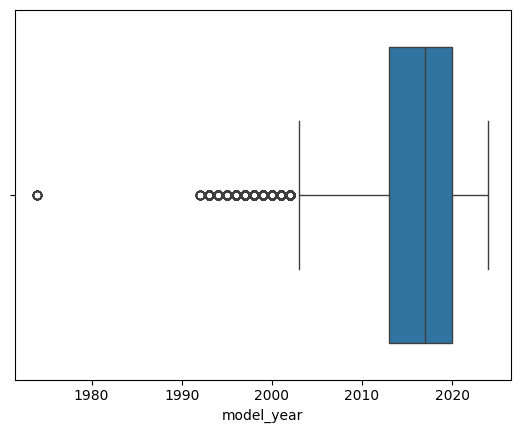

In [1354]:
sns.boxplot(x=df['model_year'])

In [1355]:
print(df['model_year'].min())
print(df['model_year'].max())

1974
2024


In [1356]:
df = df[df['model_year'] != 1974]

In [1357]:
from datetime import datetime

In [1358]:
df['car_age'] = datetime.now().year - df['model_year']

In [1359]:
df.drop('model_year', axis=1, inplace=True)

In [1360]:
df['car_age'] = df['car_age'].clip(upper=20)

<Axes: xlabel='car_age'>

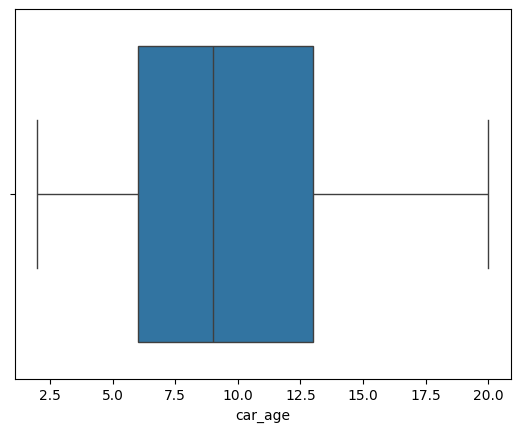

In [1361]:
sns.boxplot(x=df['car_age'])

In [1362]:
# milage

<Axes: xlabel='milage'>

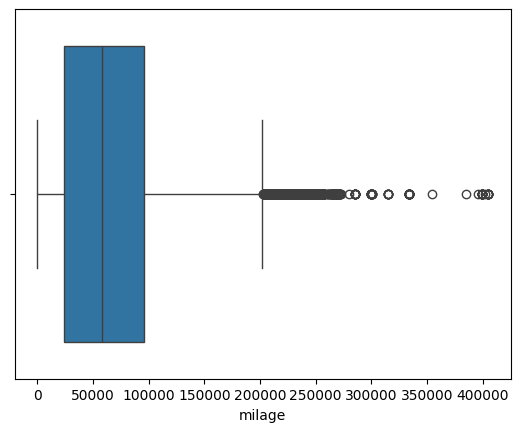

In [1363]:
sns.boxplot(x=df['milage'])

In [1364]:
df['milage'].describe()

,milage
count,188521.000000
mean,65705.171084
std,49797.964242
min,100.000000
25%,24115.000000
50%,57785.000000
75%,95400.000000
max,405000.000000


In [1365]:
Q1 = df['milage'].quantile(0.25)
Q3 = df['milage'].quantile(0.75)

In [1366]:
IQR = Q3 - Q1

In [1367]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [1368]:
print(lower_limit)
print(upper_limit)

-82812.5
202327.5


In [1369]:
min_val = df['milage'].min()
max_val = df['milage'].max()

if min_val < lower_limit and max_val > upper_limit:
    print("Both lower and upper outliers exist")

elif min_val < lower_limit:
    print("Lower outliers exist")

elif max_val > upper_limit:
    print("Upper outliers exist")

else:
    print("No outliers detected")

Upper outliers exist


In [1370]:
df['milage'].skew()

np.float64(0.8950706226255637)

In [1371]:
cap = df['milage'].quantile(0.99)
df['milage'] = df['milage'].clip(upper=cap)

In [1372]:
df['milage'].skew()

np.float64(0.7362752916129952)

<Axes: xlabel='milage'>

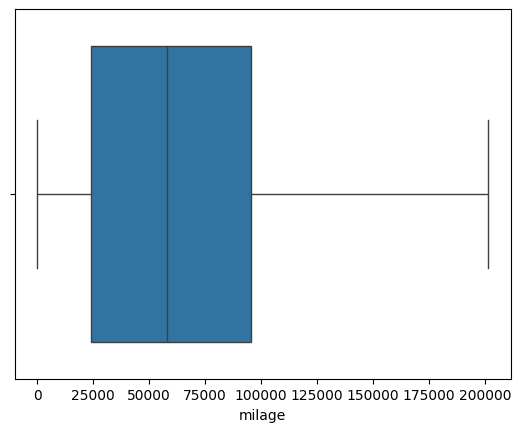

In [1373]:
sns.boxplot(x=df['milage'])

In [1374]:
# engine

In [1375]:
df['engine'].isnull().sum()

np.int64(0)

In [1376]:
# --- STEP 1: EXTRACTION FROM ENGINE COLUMN ---

# 1. Horsepower
df["horsepower"] = df["engine"].str.extract(r"(\d+\.?\d*)\s*HP").astype(float)

# 2. Engine Displacement (Liters)
df["displacement"] = df["engine"].str.extract(r"(\d+\.?\d*)\s*L").astype(float)

# 3. Number of Cylinders (Fixed: Removed 'case=False' and added inline case-insensitive flag '(?i)')
extracted_cyl = df["engine"].str.extract(
    r"(?i)(\d+)\s*Cylinder|[IV](\d+)"
)
# Combine the two regex capture groups
df["cylinders"] = extracted_cyl[0].fillna(extracted_cyl[1]).astype(float)

# 4. Performance Indicators (Turbo, GDI, Valve Count)
df["is_turbo"] = df["engine"].str.contains("Turbo", case=False).astype(int)
df["is_gdi"] = df["engine"].str.contains("GDI", case=False).astype(int)
df["valves"] = df["engine"].str.extract(r"(\d+)\s*V\b").astype(float)

In [1377]:
# --- STEP 1: CLEAN KNOWN INVALID VALUES IN FUEL_TYPE ---

# --- STEP 2: EXTRACT TEMPORARY FUEL FROM ENGINE ---
fuel_pattern = (
    r"(?i)(Gasoline|Diesel|Hybrid|Flex Fuel|Electric|Plug-In Electric)"
)
df["engine_fuel"] = df["engine"].str.extract(fuel_pattern)

# Standardize engine_fuel names to match your clean array categories
fuel_mapping = {
    "gasoline": "Gasoline",
    "diesel": "Diesel",
    "hybrid": "Hybrid",
    "flex fuel": "E85 Flex Fuel",
    "electric": "Plug-In Hybrid",
    "plug-in electric": "Plug-In Hybrid",
}
df["engine_fuel"] = (
    df["engine_fuel"].str.lower().map(fuel_mapping).fillna(df["engine_fuel"])
)


# --- STEP 4: MERGE & FILL MISSING VALUES ---
# Smart Fill: Use the data extracted from 'engine' to fill NaNs in 'fuel_type'
df["fuel_type"] = df["fuel_type"].fillna(df["engine_fuel"])

# Fallback Fill: If any rows still have NaN, fill them with the most frequent value (Mode)
df["fuel_type"] = df["fuel_type"].fillna(df["fuel_type"].mode()[0])


# --- STEP 5: CLEANUP AND ONE-HOT ENCODING ---
# Drop the temporary column and the original noisy engine column
df = df.drop(columns=["engine_fuel", "engine"])

# Convert your completed fuel_type column into dummy numeric variables for your model
df = pd.get_dummies(df, columns=["fuel_type"], drop_first=True, dtype=int)

In [1378]:
df.head()

,brand,model,milage,transmission,ext_col,int_col,clean_title,price,accident_None reported,accident_Unknown,...,horsepower,displacement,cylinders,is_turbo,is_gdi,valves,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid
0,MINI,Cooper S Base,201509,A/T,Yellow,Gray,1,4200,1,0,...,172.0,1.6,4.0,0,0,NaN,0,1,0,0
1,Lincoln,Other,143250,A/T,Silver,Beige,1,4999,0,0,...,252.0,3.9,8.0,0,0,NaN,0,1,0,0
2,Chevrolet,Other,136731,A/T,Blue,Gray,1,13900,1,0,...,320.0,5.3,8.0,0,0,NaN,1,0,0,0
3,Genesis,Other,19500,Transmission w/Dual Shift Mode,Black,Black,1,45000,1,0,...,420.0,5.0,8.0,0,0,NaN,0,1,0,0
4,Mercedes-Benz,Metris Base,7388,7-Speed A/T,Black,Beige,1,97500,1,0,...,208.0,2.0,4.0,0,0,NaN,0,1,0,0


In [1379]:
df.isnull().sum()

,0
brand,0
model,0
milage,0
transmission,0
ext_col,0
int_col,0
clean_title,0
price,0
accident_None reported,0
accident_Unknown,0


In [1380]:
# List of new columns that have missing values
missing_cols = ["horsepower", "displacement", "cylinders", "valves"]

for col in missing_cols:
    # 1. Try to fill NaNs using the median of the specific Brand AND Model
    df[col] = df.groupby(["brand", "model"])[col].transform(
        lambda x: x.fillna(x.median())
    )

    # 2. If a model is rare and still has NaNs, fill it using just the Brand's median
    df[col] = df.groupby("brand")[col].transform(
        lambda x: x.fillna(x.median())
    )

    # 3. Ultimate backup: If a brand is completely unknown, fill with the global median
    df[col] = df[col].fillna(df[col].median())

In [1381]:
# Check the minimum, maximum, and average values
print(df[["horsepower", "displacement", "cylinders"]].describe())

          horsepower   displacement      cylinders
count  188521.000000  188521.000000  188521.000000
mean      343.448910       3.776549       6.324192
std       112.544528       1.342869       1.569744
min        70.000000       0.650000       3.000000
25%       265.000000       3.000000       6.000000
50%       329.000000       3.500000       6.000000
75%       404.000000       4.700000       8.000000
max      1020.000000       8.400000      12.000000


In [1382]:
df.isnull().sum()

,0
brand,0
model,0
milage,0
transmission,0
ext_col,0
int_col,0
clean_title,0
price,0
accident_None reported,0
accident_Unknown,0


In [1383]:
# Now check ouliers

In [1384]:
print(df["horsepower"].skew())
print(df["displacement"].skew())
print(df["cylinders"].skew())
print(df["valves"].skew())

0.8217684706211948
0.4856630148495911
0.21599317137587895
25.73827589011625


In [1385]:
df["valves"] = np.log1p(df["valves"])

In [1386]:
print(df["valves"].skew())

0.22784482744490425


In [1387]:
cap = df['horsepower'].quantile(0.99)
df['horsepower'] = df['horsepower'].clip(upper=cap)

In [1388]:
print(df["horsepower"].skew())

0.5782068504140946


In [1389]:
cols_to_check = ['horsepower', 'displacement', 'cylinders']

for col in cols_to_check:
    print(f"\n{col}:")
    print(df[col].describe())
    print(f"Skew: {df[col].skew():.2f}")


horsepower:
count    188521.000000
mean        342.474929
std         109.120723
min          70.000000
25%         265.000000
50%         329.000000
75%         404.000000
max         650.000000
Name: horsepower, dtype: float64
Skew: 0.58

displacement:
count    188521.000000
mean          3.776549
std           1.342869
min           0.650000
25%           3.000000
50%           3.500000
75%           4.700000
max           8.400000
Name: displacement, dtype: float64
Skew: 0.49

cylinders:
count    188521.000000
mean          6.324192
std           1.569744
min           3.000000
25%           6.000000
50%           6.000000
75%           8.000000
max          12.000000
Name: cylinders, dtype: float64
Skew: 0.22


In [1390]:
# transmission

In [1391]:
df['transmission'].value_counts(dropna = False)

,count
transmission,
A/T,49900
8-Speed A/T,20645
Transmission w/Dual Shift Mode,19255
6-Speed A/T,18044
6-Speed M/T,11997
7-Speed A/T,11124
Automatic,10690
8-Speed Automatic,8431
10-Speed A/T,8044


In [1392]:
unknown_transmission = ['–', '2', 'F', 'SCHEDULED FOR OR IN PRODUCTION']

df['transmission'] = df['transmission'].replace(unknown_transmission, np.nan)

In [1393]:
print(df['transmission'].isnull().sum())

245


In [1394]:
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

In [1395]:
print(df['transmission'].isnull().sum())

0


In [1396]:
df['transmission'].value_counts()

,count
transmission,
A/T,50145
8-Speed A/T,20645
Transmission w/Dual Shift Mode,19255
6-Speed A/T,18044
6-Speed M/T,11997
7-Speed A/T,11124
Automatic,10690
8-Speed Automatic,8431
10-Speed A/T,8044


In [1397]:
def simplify_transmission(val):
    val = str(val).upper()
    if 'CVT' in val: return 'CVT'
    if 'M/T' in val or 'MANUAL' in val: return 'Manual'
    if 'A/T' in val or 'AUTO' in val: return 'Automatic'
    return 'Other'

df['transmission'] = df['transmission'].apply(simplify_transmission)

In [1398]:
df['transmission'].value_counts()

,count
transmission,
Automatic,149712
Other,19619
Manual,16356
CVT,2834


In [1399]:
# ext_col & int_col

In [1400]:
df['ext_col'].unique()

array(['Yellow', 'Silver', 'Blue', 'Black', 'White',
       'Snowflake White Pearl Metallic', 'Gray', 'Green',
       'Santorini Black Metallic', 'Purple', 'Ebony Twilight Metallic',
       'Red', 'Magnetite Black Metallic', 'Diamond Black', 'Vega Blue',
       'Beige', 'Gold', 'Platinum White Pearl', 'Metallic',
       'White Frost Tri-Coat', 'Firecracker Red Clearcoat',
       'Phytonic Blue Metallic', 'Blu', 'Orange', 'Brown',
       'Brilliant Silver Metallic', 'Black Raven', 'Black Clearcoat',
       'Firenze Red', 'Agate Black Metallic', 'Glacial White Pearl',
       'Majestic Plum Metallic', 'designo Diamond White Metallic',
       'Oxford White', 'Black Sapphire Metallic', 'Mythos Black',
       'Granite Crystal Clearcoat Metallic', 'White Diamond Tri-Coat',
       'Magnetite Gray Metallic', 'Carpathian Grey Premium Metallic',
       'designo Diamond White Bright',
       'Phantom Black Pearl Effect / Black Roof', 'Nebula Gray Pearl',
       'Deep Crystal Blue Mica', 'Flame Red

In [1401]:
color_map = {
    'black': 'Black', 'white': 'White', 'gray': 'Gray', 'grey': 'Gray',
    'silver': 'Silver', 'blue': 'Blue', 'red': 'Red', 'green': 'Green',
    'brown': 'Brown', 'beige': 'Beige', 'gold': 'Gold', 'orange': 'Orange',
    'yellow': 'Yellow', 'purple': 'Purple'
}

def map_color(val):
    val_lower = str(val).lower()
    for key, basic in color_map.items():
        if key in val_lower:
            return basic
    return 'Other'

df['ext_col'] = df['ext_col'].apply(map_color)
df['int_col'] = df['int_col'].apply(map_color)

In [1402]:
df.head()

,brand,model,milage,transmission,ext_col,int_col,clean_title,price,accident_None reported,accident_Unknown,...,horsepower,displacement,cylinders,is_turbo,is_gdi,valves,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid
0,MINI,Cooper S Base,201509,Automatic,Yellow,Gray,1,4200,1,0,...,172.0,1.6,4.0,0,0,2.833213,0,1,0,0
1,Lincoln,Other,143250,Automatic,Silver,Beige,1,4999,0,0,...,252.0,3.9,8.0,0,0,2.833213,0,1,0,0
2,Chevrolet,Other,136731,Automatic,Blue,Gray,1,13900,1,0,...,320.0,5.3,8.0,0,0,2.833213,1,0,0,0
3,Genesis,Other,19500,Other,Black,Black,1,45000,1,0,...,420.0,5.0,8.0,0,0,2.833213,0,1,0,0
4,Mercedes-Benz,Metris Base,7388,Automatic,Black,Beige,1,97500,1,0,...,208.0,2.0,4.0,0,0,2.833213,0,1,0,0


<Axes: xlabel='price'>

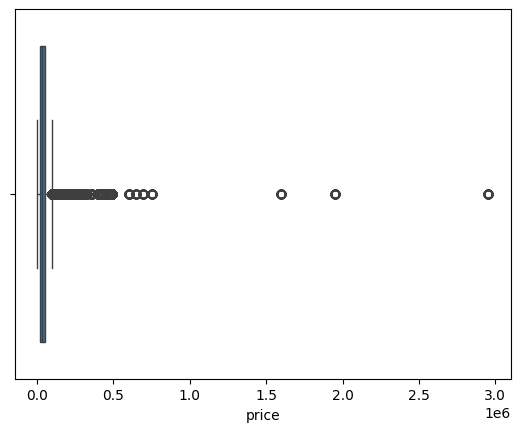

In [1403]:
# PRICE
sns.boxplot(x=df['price'])

In [1404]:
df['price'].skew()

np.float64(20.26941033624218)

In [1405]:
df = df[df['price'] < 300000]

In [1406]:
df['price'] = np.log1p(df['price'])


In [1407]:
df['price'].skew()

np.float64(-0.14068778101217902)

<Axes: xlabel='price'>

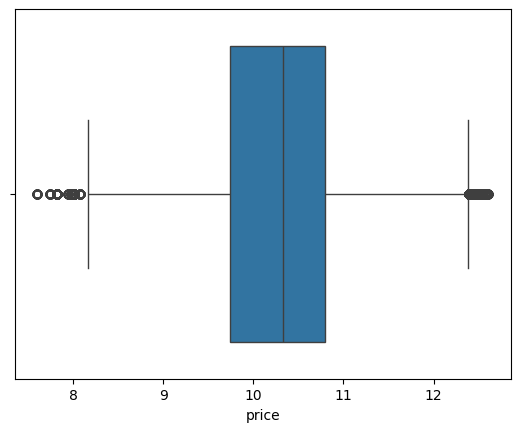

In [1408]:
sns.boxplot(x=df['price'])

In [1409]:
print(df.shape)

(187331, 21)


In [1410]:
df.head()

,brand,model,milage,transmission,ext_col,int_col,clean_title,price,accident_None reported,accident_Unknown,...,horsepower,displacement,cylinders,is_turbo,is_gdi,valves,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid
0,MINI,Cooper S Base,201509,Automatic,Yellow,Gray,1,8.343078,1,0,...,172.0,1.6,4.0,0,0,2.833213,0,1,0,0
1,Lincoln,Other,143250,Automatic,Silver,Beige,1,8.517193,0,0,...,252.0,3.9,8.0,0,0,2.833213,0,1,0,0
2,Chevrolet,Other,136731,Automatic,Blue,Gray,1,9.539716,1,0,...,320.0,5.3,8.0,0,0,2.833213,1,0,0,0
3,Genesis,Other,19500,Other,Black,Black,1,10.714440,1,0,...,420.0,5.0,8.0,0,0,2.833213,0,1,0,0
4,Mercedes-Benz,Metris Base,7388,Automatic,Black,Beige,1,11.487618,1,0,...,208.0,2.0,4.0,0,0,2.833213,0,1,0,0


In [1411]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 187331 entries, 0 to 188532
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     187331 non-null  object 
 1   model                     187331 non-null  object 
 2   milage                    187331 non-null  int64  
 3   transmission              187331 non-null  object 
 4   ext_col                   187331 non-null  object 
 5   int_col                   187331 non-null  object 
 6   clean_title               187331 non-null  int64  
 7   price                     187331 non-null  float64
 8   accident_None reported    187331 non-null  int64  
 9   accident_Unknown          187331 non-null  int64  
 10  car_age                   187331 non-null  int64  
 11  horsepower                187331 non-null  float64
 12  displacement              187331 non-null  float64
 13  cylinders                 187331 non-null  float6

In [1412]:
df['cylinders'].value_counts()

,count
cylinders,
6.0,83090
8.0,61709
4.0,37940
12.0,1575
5.0,1083
10.0,1057
7.0,474
3.0,403


In [1413]:
df['cylinders'] = df['cylinders'].astype('Int64')

In [1414]:
df['horsepower'].value_counts()

,count
horsepower,
300.0,6950
355.0,5860
375.0,4816
420.0,4331
395.0,4298
...,...
332.5,1
111.0,1
282.5,1


In [1415]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 187331 entries, 0 to 188532
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     187331 non-null  object 
 1   model                     187331 non-null  object 
 2   milage                    187331 non-null  int64  
 3   transmission              187331 non-null  object 
 4   ext_col                   187331 non-null  object 
 5   int_col                   187331 non-null  object 
 6   clean_title               187331 non-null  int64  
 7   price                     187331 non-null  float64
 8   accident_None reported    187331 non-null  int64  
 9   accident_Unknown          187331 non-null  int64  
 10  car_age                   187331 non-null  int64  
 11  horsepower                187331 non-null  float64
 12  displacement              187331 non-null  float64
 13  cylinders                 187331 non-null  Int64 

In [1416]:
df.drop('valves', axis=1, inplace=True)

In [1417]:
df.corr(numeric_only=True)

,milage,clean_title,price,accident_None reported,accident_Unknown,car_age,horsepower,displacement,cylinders,is_turbo,is_gdi,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid
milage,1.000000,0.246126,-0.715030,-0.308477,-0.036473,0.701426,-0.400523,-0.015791,-0.057599,-0.197218,-0.175657,0.130530,0.042334,-0.114324,-0.120137
clean_title,0.246126,1.000000,-0.203794,-0.055587,-0.319128,0.281244,-0.007273,0.081197,0.052045,-0.417177,-0.343368,0.044440,0.013974,-0.089856,0.015059
price,-0.715030,-0.203794,1.000000,0.284491,0.033708,-0.704289,0.516222,0.151385,0.198918,0.174920,0.162676,-0.076490,-0.079820,0.090968,0.104889
accident_None reported,-0.308477,-0.055587,0.284491,1.000000,-0.207111,-0.258637,0.183998,0.022284,0.049881,0.092888,0.063508,-0.066578,-0.015026,0.041408,0.064459
accident_Unknown,-0.036473,-0.319128,0.033708,-0.207111,1.000000,-0.033393,0.017029,0.009091,0.004237,0.027475,0.022877,0.001968,-0.008972,0.000505,0.000442
car_age,0.701426,0.281244,-0.704289,-0.258637,-0.033393,1.000000,-0.357511,0.014723,0.014252,-0.237821,-0.225786,0.068128,0.122047,-0.140451,-0.137461
horsepower,-0.400523,-0.007273,0.516222,0.183998,0.017029,-0.357511,1.000000,0.572252,0.654903,0.042745,0.006916,-0.026921,-0.090562,-0.005535,0.177892
displacement,-0.015791,0.081197,0.151385,0.022284,0.009091,0.014723,0.572252,1.000000,0.870454,-0.146022,-0.063874,0.126436,-0.090036,-0.107456,-0.022340
cylinders,-0.057599,0.052045,0.198918,0.049881,0.004237,0.014252,0.654903,0.870454,1.000000,-0.094589,-0.055503,0.088321,-0.021192,-0.070422,-0.044568
is_turbo,-0.197218,-0.417177,0.174920,0.092888,0.027475,-0.237821,0.042745,-0.146022,-0.094589,1.000000,0.515583,-0.043037,0.037694,0.006245,-0.046821


<Axes: xlabel='price', ylabel='Count'>

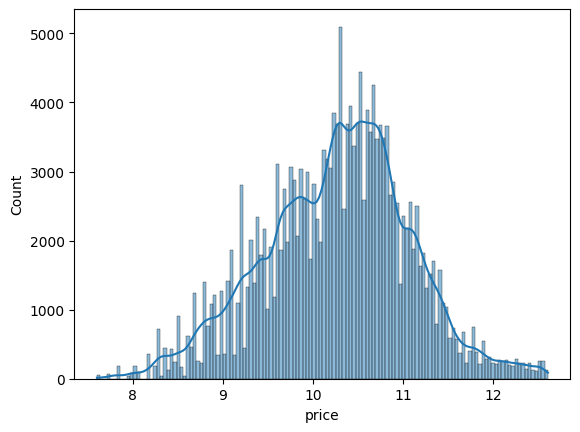

In [1418]:
sns.histplot(df['price'], kde=True)

In [1419]:
df['cylinders'] = df['cylinders'].astype(float)

In [1420]:
df['age_x_milage'] = df['car_age'] * df['milage']
df['hp_per_age'] = df['horsepower'] / (df['car_age'] + 1)

In [1421]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 187331 entries, 0 to 188532
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     187331 non-null  object 
 1   model                     187331 non-null  object 
 2   milage                    187331 non-null  int64  
 3   transmission              187331 non-null  object 
 4   ext_col                   187331 non-null  object 
 5   int_col                   187331 non-null  object 
 6   clean_title               187331 non-null  int64  
 7   price                     187331 non-null  float64
 8   accident_None reported    187331 non-null  int64  
 9   accident_Unknown          187331 non-null  int64  
 10  car_age                   187331 non-null  int64  
 11  horsepower                187331 non-null  float64
 12  displacement              187331 non-null  float64
 13  cylinders                 187331 non-null  float6

In [1422]:
print(df.shape)
print(df.dtypes)

(187331, 22)
brand                        object
model                        object
milage                        int64
transmission                 object
ext_col                      object
int_col                      object
clean_title                   int64
price                       float64
accident_None reported        int64
accident_Unknown              int64
car_age                       int64
horsepower                  float64
displacement                float64
cylinders                   float64
is_turbo                      int64
is_gdi                        int64
fuel_type_E85 Flex Fuel       int64
fuel_type_Gasoline            int64
fuel_type_Hybrid              int64
fuel_type_Plug-In Hybrid      int64
age_x_milage                  int64
hp_per_age                  float64
dtype: object


In [1423]:
df.isnull().sum()

,0
brand,0
model,0
milage,0
transmission,0
ext_col,0
int_col,0
clean_title,0
price,0
accident_None reported,0
accident_Unknown,0


In [1424]:
if 'engine' in df.columns:
    df.drop('engine', axis=1, inplace=True)

# check what object columns remain
print(df.select_dtypes(include='object').columns.tolist())

['brand', 'model', 'transmission', 'ext_col', 'int_col']


# Model Building

In [1425]:
!pip install category_encoders

In [1426]:
from xgboost import XGBRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

cat_cols = ["brand", "model", "transmission", "ext_col", "int_col"]
target = "price"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 1. FREQUENCY ENCODING ──
X_train_freq = X_train.copy()
X_test_freq  = X_test.copy()

for col in cat_cols:
    freq_map = X_train_freq[col].value_counts().to_dict()
    X_train_freq[col] = X_train_freq[col].map(freq_map)
    X_test_freq[col]  = X_test_freq[col].map(freq_map).fillna(0)

# ── 2. ORDINAL ENCODING ──
X_train_ord = X_train.copy()
X_test_ord  = X_test.copy()

ord_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)
X_train_ord[cat_cols] = ord_encoder.fit_transform(X_train_ord[cat_cols])
X_test_ord[cat_cols]  = ord_encoder.transform(X_test_ord[cat_cols])

# ── 3. TARGET ENCODING ──
X_train_tgt = X_train.copy()
X_test_tgt  = X_test.copy()

target_maps = {}

for col in cat_cols:
    tgt_map     = y_train.groupby(X_train_tgt[col]).mean().to_dict()
    global_mean = y_train.mean()
    target_maps[col] = tgt_map
    X_train_tgt[col] = X_train_tgt[col].map(tgt_map)
    X_test_tgt[col]  = X_test_tgt[col].map(tgt_map).fillna(global_mean)

# ── TRAIN & EVALUATE ──
def train_eval(X_tr, X_te, y_tr, y_te, label):
    model = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        verbose=False
    )
    preds = model.predict(X_te)
    r2  = r2_score(y_te, preds)
    mae = mean_absolute_error(np.expm1(y_te), np.expm1(preds))
    print(f"[{label}]  MAE ($): {mae:,.0f}  |  R²: {r2:.4f}")
    return model, preds

print("=" * 55)
model_freq, pred_freq = train_eval(X_train_freq, X_test_freq, y_train, y_test, "Frequency Encoding")
model_ord,  pred_ord  = train_eval(X_train_ord,  X_test_ord,  y_train, y_test, "Ordinal Encoding  ")
model_tgt,  pred_tgt  = train_eval(X_train_tgt,  X_test_tgt,  y_train, y_test, "Target Encoding   ")
print("=" * 55)

[Frequency Encoding]  MAE ($): 13,478  |  R²: 0.6833
[Ordinal Encoding  ]  MAE ($): 13,501  |  R²: 0.6829
[Target Encoding   ]  MAE ($): 13,486  |  R²: 0.6838


In [1427]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':     [500, 1000, 2000],
    'max_depth':        [4, 6, 8, 10],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 7, 10],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],
    'reg_lambda':       [1.0, 1.5, 2.0, 3.0]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42
)

search.fit(X_train_tgt, y_train)

print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=4, min_child_weight=7, n_estimators=500, reg_alpha=1.0, reg_lambda=1.0, subsample=0.9; total time=  12.1s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=4, min_child_weight=7, n_estimators=500, reg_alpha=1.0, reg_lambda=1.0, subsample=0.9; total time=  14.2s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=4, min_child_weight=7, n_estimators=500, reg_alpha=1.0, reg_lambda=1.0, subsample=0.9; total time=   4.0s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=6, min_child_weight=3, n_estimators=1000, reg_alpha=0.1, reg_lambda=3.0, subsample=0.6; total time=  14.3s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=6, min_child_weight=3, n_estimators=1000, reg_alpha=0.1, reg_lambda=3.0, subsample=0.6; total time=  14.2s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=6, min_child_weight=3, n_estimators=1000, re

TEST

In [1428]:
test = pd.read_csv('test.csv')
test_ids = test['id']
print(test.shape)

(125690, 12)


In [1429]:
test.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
1,188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
2,188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,NaN
3,188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,NaN
4,188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes


In [1430]:
test.drop('id', axis=1, inplace=True)

In [1431]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         125690 non-null  object
 1   model         125690 non-null  object
 2   model_year    125690 non-null  int64 
 3   milage        125690 non-null  int64 
 4   fuel_type     122307 non-null  object
 5   engine        125690 non-null  object
 6   transmission  125690 non-null  object
 7   ext_col       125690 non-null  object
 8   int_col       125690 non-null  object
 9   accident      124058 non-null  object
 10  clean_title   111451 non-null  object
dtypes: int64(2), object(9)
memory usage: 10.5+ MB


In [1432]:
test['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,110533
Hybrid,4676
E85 Flex Fuel,3523
Diesel,2686
–,538
Plug-In Hybrid,337
not supported,14


In [1433]:
test['fuel_type'] = test['fuel_type'].replace(['–' , 'not supported'],np.nan)

In [1434]:
test['fuel_type'] = test['fuel_type'].fillna(test['fuel_type'].mode()[0])

In [1435]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         125690 non-null  object
 1   model         125690 non-null  object
 2   model_year    125690 non-null  int64 
 3   milage        125690 non-null  int64 
 4   fuel_type     125690 non-null  object
 5   engine        125690 non-null  object
 6   transmission  125690 non-null  object
 7   ext_col       125690 non-null  object
 8   int_col       125690 non-null  object
 9   accident      124058 non-null  object
 10  clean_title   111451 non-null  object
dtypes: int64(2), object(9)
memory usage: 10.5+ MB


In [1436]:
test['accident'].value_counts(dropna=False)

,count
accident,
None reported,96263
At least 1 accident or damage reported,27795
NaN,1632


In [1437]:
test['accident'] = test['accident'].fillna('unknown')

In [1438]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         125690 non-null  object
 1   model         125690 non-null  object
 2   model_year    125690 non-null  int64 
 3   milage        125690 non-null  int64 
 4   fuel_type     125690 non-null  object
 5   engine        125690 non-null  object
 6   transmission  125690 non-null  object
 7   ext_col       125690 non-null  object
 8   int_col       125690 non-null  object
 9   accident      125690 non-null  object
 10  clean_title   111451 non-null  object
dtypes: int64(2), object(9)
memory usage: 10.5+ MB


In [1439]:
test['clean_title'].value_counts(dropna=False)

,count
clean_title,
Yes,111451
NaN,14239


In [1440]:
test['clean_title'] = test['clean_title'].fillna('Unknown')

In [1441]:
test['clean_title'] = test['clean_title'].map({'Yes' : 1, 'Unknown' : 0})

In [1442]:
counts = test['brand'].value_counts()
rare_brands = counts[counts<100].index
test['brand'] = test['brand'].replace(rare_brands , 'Other')

In [1443]:
counts = test['model'].value_counts()
rare_models  = counts[counts<100].index
test['model'] =  test['model'].replace(rare_models , 'Other')

In [1444]:
from datetime import datetime
test['car_age'] = datetime.now().year - test['model_year']
test['car_age'] = test['car_age'].clip(upper = 20)
test.drop('model_year' , axis = 1 , inplace = True)

In [1445]:
cap = test['milage'].quantile(0.99)
test['milage'] = test['milage'].clip(upper = cap)

In [1446]:
test["horsepower"] = test["engine"].str.extract(r"(\d+\.?\d*)\s*HP").astype(float)
test["displacement"] = test["engine"].str.extract(r"(\d+\.?\d*)\s*L").astype(float)
extracted_cyl = test["engine"].str.extract(r"(?i)(\d+)\s*Cylinder|[IV](\d+)")
test["cylinders"] = extracted_cyl[0].fillna(extracted_cyl[1]).astype(float)
test["is_turbo"] = test["engine"].str.contains("Turbo", case=False).astype(int)
test["is_gdi"] = test["engine"].str.contains("GDI", case=False).astype(int)
test["valves"] = test["engine"].str.extract(r"(\d+)\s*V\b").astype(float)

In [1447]:
test.drop('engine' , axis = 1 , inplace =True)

In [1448]:
print(test['horsepower'].skew())
print(test['displacement'].skew())
print(test['cylinders'].skew())
print(test['valves'].skew())

0.7812248967547887
0.4917437399025551
0.22295912056439343
26.69388074683673


In [1449]:
test['horsepower'] = test['horsepower'].fillna(test['horsepower'].median())

test['displacement'] = test['displacement'].fillna(test['displacement'].mean())

test['cylinders'] = test['cylinders'].fillna(test['cylinders'].median())

test['valves'] = np.log1p(test['valves'])

In [1450]:
print(test['horsepower'].skew())
print(test['displacement'].skew())
print(test['cylinders'].skew())
print(test['valves'].skew())

0.9317158230730012
0.5005422188885614
0.28495135324811605
0.6654647439699175


In [1451]:
test['horsepower'] = np.log1p(test['horsepower'])

In [1452]:
test['transmission'].value_counts(dropna=False)

,count
transmission,
A/T,33132
8-Speed A/T,13941
Transmission w/Dual Shift Mode,12824
6-Speed A/T,12061
6-Speed M/T,7865
7-Speed A/T,7374
Automatic,7175
8-Speed Automatic,5546
10-Speed A/T,5303


In [1453]:
unknown_transmission = ['2' , 'F' , '–' , 'SCHEDULED FOR OR IN PRODUCTION']

test['transmission'] = test['transmission'].replace(unknown_transmission , np.nan)

In [1454]:
print(test['transmission'].isnull().sum())

155


In [1455]:
test['transmission'] = test['transmission'].fillna(test['transmission'].mode()[0])

In [1456]:
test['transmission'].value_counts()

,count
transmission,
A/T,33287
8-Speed A/T,13941
Transmission w/Dual Shift Mode,12824
6-Speed A/T,12061
6-Speed M/T,7865
7-Speed A/T,7374
Automatic,7175
8-Speed Automatic,5546
10-Speed A/T,5303


In [1457]:
def simplify_transmission(val):
    val = str(val).upper()
    if 'CVT' in val: return 'CVT'
    if 'M/T' in val or 'MANUAL' in val: return 'Manual'
    if 'A/T' in val or 'AUTO' in val: return 'Automatic'
    return 'Other'

test['transmission'] = test['transmission'].apply(simplify_transmission)

In [1458]:
test['transmission'].value_counts()

,count
transmission,
Automatic,99910
Other,13105
Manual,10785
CVT,1890


In [1459]:
map_color = {
    'black': 'Black', 'white': 'White', 'gray': 'Gray', 'grey': 'Gray',
    'silver': 'Silver', 'blue': 'Blue', 'red': 'Red', 'green': 'Green',
    'brown': 'Brown', 'beige': 'Beige', 'gold': 'Gold', 'orange': 'Orange',
    'yellow': 'Yellow', 'purple': 'Purple'
}

def map_color(val):
    val_lower = str(val).lower()
    for key, basic in color_map.items():
        if key in val_lower:
            return basic
    return 'Other'


In [1460]:
test['ext_col'] = test['ext_col'].apply(map_color)
test['int_col'] = test['int_col'].apply(map_color)

In [1461]:
test['accident'].value_counts(dropna=False)

,count
accident,
None reported,96263
At least 1 accident or damage reported,27795
unknown,1632


In [1462]:
test['accident'] = test['accident'].fillna('Unknown')

In [1463]:
test['accident'].value_counts()

,count
accident,
None reported,96263
At least 1 accident or damage reported,27795
unknown,1632


In [1464]:
test = pd.get_dummies(test, columns=['accident'], drop_first=True, dtype=int)

In [1465]:
test['fuel_type'].value_counts(dropna=False)

,count
fuel_type,
Gasoline,114468
Hybrid,4676
E85 Flex Fuel,3523
Diesel,2686
Plug-In Hybrid,337


In [1466]:
fuel_pattern = r'(?i)(Gasoline|Diesel|Hybrid|Flex Fuel|Electric|Plug-In Electric)'
test['engine_fuel'] = test['engine'] if 'engine' in test.columns else np.nan
test = pd.get_dummies(test, columns=['fuel_type'], drop_first=True, dtype=int)

In [1467]:
print(test.shape)
print(test.columns.tolist())

(125690, 21)
['brand', 'model', 'milage', 'transmission', 'ext_col', 'int_col', 'clean_title', 'car_age', 'horsepower', 'displacement', 'cylinders', 'is_turbo', 'is_gdi', 'valves', 'accident_None reported', 'accident_unknown', 'engine_fuel', 'fuel_type_E85 Flex Fuel', 'fuel_type_Gasoline', 'fuel_type_Hybrid', 'fuel_type_Plug-In Hybrid']


In [1468]:
test.head()

,brand,model,milage,transmission,ext_col,int_col,clean_title,car_age,horsepower,displacement,...,is_turbo,is_gdi,valves,accident_None reported,accident_unknown,engine_fuel,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid
0,Land,Other,98000,Automatic,White,Beige,1,11,5.484797,2.0,...,0,0,NaN,1,0,NaN,0,1,0,0
1,Land,Rover Defender SE,9142,Automatic,Silver,Black,1,6,5.981414,3.0,...,0,0,NaN,1,0,NaN,0,0,1,0
2,Ford,Expedition Limited,28121,Automatic,White,Other,0,4,5.796058,3.5,...,1,0,3.218876,1,0,NaN,0,1,0,0
3,Audi,Other,61258,Automatic,Yellow,Black,0,10,5.796058,2.0,...,0,0,NaN,1,0,NaN,0,1,0,0
4,Audi,A6 2.0T Premium Plus,59000,Automatic,Gray,Black,1,8,5.533389,2.0,...,0,0,NaN,1,0,NaN,0,1,0,0


In [1469]:
test.rename(columns={'accident_unknown': 'accident_Unknown'}, inplace=True)

In [1470]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     125690 non-null  object 
 1   model                     125690 non-null  object 
 2   milage                    125690 non-null  int64  
 3   transmission              125690 non-null  object 
 4   ext_col                   125690 non-null  object 
 5   int_col                   125690 non-null  object 
 6   clean_title               125690 non-null  int64  
 7   car_age                   125690 non-null  int64  
 8   horsepower                125690 non-null  float64
 9   displacement              125690 non-null  float64
 10  cylinders                 125690 non-null  float64
 11  is_turbo                  125690 non-null  int64  
 12  is_gdi                    125690 non-null  int64  
 13  valves                    15621 non-null   f

In [1471]:
test.drop('engine_fuel', axis=1, inplace=True)

In [1472]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     125690 non-null  object 
 1   model                     125690 non-null  object 
 2   milage                    125690 non-null  int64  
 3   transmission              125690 non-null  object 
 4   ext_col                   125690 non-null  object 
 5   int_col                   125690 non-null  object 
 6   clean_title               125690 non-null  int64  
 7   car_age                   125690 non-null  int64  
 8   horsepower                125690 non-null  float64
 9   displacement              125690 non-null  float64
 10  cylinders                 125690 non-null  float64
 11  is_turbo                  125690 non-null  int64  
 12  is_gdi                    125690 non-null  int64  
 13  valves                    15621 non-null   f

In [1473]:
from sklearn.model_selection import train_test_split

target = "price"
cat_cols = ["brand", "model", "transmission", "ext_col", "int_col"]

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("y_train defined:", y_train.shape)

y_train defined: (149864,)


In [1474]:
target_maps = {}

for col in cat_cols:
    tgt_map = y_train.groupby(X_train[col]).mean().to_dict()
    target_maps[col] = tgt_map

print("target_maps defined for:", list(target_maps.keys()))

target_maps defined for: ['brand', 'model', 'transmission', 'ext_col', 'int_col']


In [1475]:
cat_cols = ["brand", "model", "transmission", "ext_col", "int_col"]

X_test_final = test.copy()

for col in cat_cols:
    global_mean = y_train.mean()
    X_test_final[col] = X_test_final[col].map(target_maps[col]).fillna(global_mean)

print(X_test_final.dtypes)
print(X_test_final.isnull().sum())

brand                       float64
model                       float64
milage                        int64
transmission                float64
ext_col                     float64
int_col                     float64
clean_title                   int64
car_age                       int64
horsepower                  float64
displacement                float64
cylinders                   float64
is_turbo                      int64
is_gdi                        int64
valves                      float64
accident_None reported        int64
accident_Unknown              int64
fuel_type_E85 Flex Fuel       int64
fuel_type_Gasoline            int64
fuel_type_Hybrid              int64
fuel_type_Plug-In Hybrid      int64
dtype: object
brand                            0
model                            0
milage                           0
transmission                     0
ext_col                          0
int_col                          0
clean_title                      0
car_age              

In [1476]:
X_test_final = test.copy()

for col in cat_cols:
    global_mean = y_train.mean()
    X_test_final[col] = X_test_final[col].map(target_maps[col]).fillna(global_mean)

print(X_test_final.isnull().sum())

brand                            0
model                            0
milage                           0
transmission                     0
ext_col                          0
int_col                          0
clean_title                      0
car_age                          0
horsepower                       0
displacement                     0
cylinders                        0
is_turbo                         0
is_gdi                           0
valves                      110069
accident_None reported           0
accident_Unknown                 0
fuel_type_E85 Flex Fuel          0
fuel_type_Gasoline               0
fuel_type_Hybrid                 0
fuel_type_Plug-In Hybrid         0
dtype: int64


In [1477]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

cat_cols = ["brand", "model", "transmission", "ext_col", "int_col"]
target = "price"

# split
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# target encoding
X_train_tgt = X_train.copy()
X_test_tgt  = X_test.copy()
target_maps  = {}

for col in cat_cols:
    tgt_map     = y_train.groupby(X_train_tgt[col]).mean().to_dict()
    global_mean = y_train.mean()
    target_maps[col] = tgt_map
    X_train_tgt[col] = X_train_tgt[col].map(tgt_map)
    X_test_tgt[col]  = X_test_tgt[col].map(tgt_map).fillna(global_mean)

# train model
model_tgt = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

model_tgt.fit(
    X_train_tgt, y_train,
    eval_set=[(X_test_tgt, y_test)],
    verbose=200
)

print("Done! Model trained.")

[0]	validation_0-rmse:0.78882
[200]	validation_0-rmse:0.46005
[400]	validation_0-rmse:0.45810
[600]	validation_0-rmse:0.45734
[735]	validation_0-rmse:0.45725
Done! Model trained.


In [1478]:
X_test_final = test.copy()

for col in cat_cols:
    global_mean = y_train.mean()
    X_test_final[col] = X_test_final[col].map(target_maps[col]).fillna(global_mean)

print(X_test_final.isnull().sum())

brand                            0
model                            0
milage                           0
transmission                     0
ext_col                          0
int_col                          0
clean_title                      0
car_age                          0
horsepower                       0
displacement                     0
cylinders                        0
is_turbo                         0
is_gdi                           0
valves                      110069
accident_None reported           0
accident_Unknown                 0
fuel_type_E85 Flex Fuel          0
fuel_type_Gasoline               0
fuel_type_Hybrid                 0
fuel_type_Plug-In Hybrid         0
dtype: int64


In [1479]:
# add missing columns to test
X_test_final['age_x_milage'] = X_test_final['car_age'] * X_test_final['milage']
X_test_final['hp_per_age'] = X_test_final['horsepower'] / (X_test_final['car_age'] + 1)

# drop valves
X_test_final.drop('valves', axis=1, inplace=True)

# reorder columns to match train exactly
X_test_final = X_test_final[X_train_tgt.columns]

print(X_test_final.shape)
print(X_test_final.columns.tolist())

(125690, 21)
['brand', 'model', 'milage', 'transmission', 'ext_col', 'int_col', 'clean_title', 'accident_None reported', 'accident_Unknown', 'car_age', 'horsepower', 'displacement', 'cylinders', 'is_turbo', 'is_gdi', 'fuel_type_E85 Flex Fuel', 'fuel_type_Gasoline', 'fuel_type_Hybrid', 'fuel_type_Plug-In Hybrid', 'age_x_milage', 'hp_per_age']


In [1480]:
preds_log = model_tgt.predict(X_test_final)
preds_final = np.expm1(preds_log)
print(preds_final[:5])

[10565.378 33512.4   23646.428 15078.822 14452.701]


In [1481]:
submission = pd.DataFrame({
    'id': test_ids,
    'price': preds_final
})
print(submission.head())
submission.to_csv('submission.csv', index=False)

       id         price
0  188533  10565.377930
1  188534  33512.398438
2  188535  23646.427734
3  188536  15078.822266
4  188537  14452.701172


In [1482]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
from sklearn.metrics import mean_squared_error

# your validation set performance
y_pred_val = model_tgt.predict(X_test_tgt)

print("Validation R²:", r2_score(y_test, y_pred_val))
print("Validation MAE ($):", round(mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_val)), 2))
print("Validation RMSE ($):", round(np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_val))), 2))

Validation R²: 0.6837663649713726
Validation MAE ($): 13485.68
Validation RMSE ($): 27440.81


In [1483]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>